In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from datetime import datetime

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error

In [2]:
data = pd.read_csv("Data TA (Bulanan).csv")
data['Tanggal'] = pd.to_datetime(data['Tanggal'], dayfirst=True) #ubah format tanggal
# Mengkonversi data ke float
data['Produksi'] = data['Produksi'].astype(float)
data['Harga'] = data['Harga'].astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Tanggal   60 non-null     datetime64[ns]
 1   Harga     60 non-null     float64       
 2   Produksi  60 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 1.5 KB


In [ ]:
df_input =data[['Harga','Produksi']]

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_input)

features = data_scaled
target = data_scaled
# artinya kedua variabel digunakan untuk input dan output

data_scaled


array([[0.09274194, 1.        ],
       [0.10483871, 0.41694819],
       [0.01451613, 0.39105162],
       [0.        , 0.13286847],
       [0.08064516, 0.08540365],
       [0.14919355, 0.15653974],
       [0.35483871, 0.04209598],
       [0.91935484, 0.0312385 ],
       [0.91935484, 0.30502318],
       [0.27419355, 0.13768586],
       [0.35483871, 0.29529057],
       [0.14516129, 0.27614325],
       [0.17741935, 0.04635094],
       [0.56451613, 0.04128901],
       [0.56451613, 0.4292729 ],
       [0.27822581, 0.13538721],
       [0.10887097, 0.17278929],
       [0.00403226, 0.41633685],
       [0.00403226, 0.13783259],
       [0.03629032, 0.03016253],
       [0.11290323, 0.11801279],
       [0.09274194, 0.04556842],
       [0.24596774, 0.07949806],
       [0.24596774, 0.24308172],
       [0.64516129, 0.50276487],
       [0.86290323, 0.11600269],
       [0.42741935, 0.16494695],
       [0.42741935, 0.20522847],
       [0.22983871, 0.13574912],
       [0.12096774, 0.17419049],
       [0.

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(features, target, test_size=0.4, shuffle=False)

print(xtrain.shape,xtest.shape)
print(ytrain.shape,ytest.shape)

(36, 2) (24, 2)
(36, 2) (24, 2)


In [5]:
win_length= 6
batch_size= 1
num_features= 2
train_generator = TimeseriesGenerator(features, data_scaled, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator = TimeseriesGenerator(xtest, ytest, length=win_length, batch_size=batch_size)

In [ ]:
# Membuat model
model = tf.keras.Sequential()

model.add(tf.keras.layers.LSTM(32,input_shape=(win_length,num_features),return_sequences=True)) #
model.add(tf.keras.layers.LSTM(32,input_shape=(win_length,num_features),return_sequences=False))

# Output
model.add(tf.keras.layers.Dense(2)) #
model.summary()


model.compile(
    loss=tf.losses.MeanSquaredError(),
    optimizer=tf.optimizers.Adam(),
)

# Gunakan callback custom_early_stopping saat melakukan pelatihan model
history = model.fit( #
    train_generator,
    epochs=500,
    shuffle=False)

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 32)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,866 (50.26 KB)

 Trainable params: 12,866 (50.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
42/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1112

c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1002
Epoch 2/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0596
Epoch 3/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0565
Epoch 4/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0546
Epoch 5/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0533
Epoch 6/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0522
Epoch 7/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0512
Epoch 8/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0504
Epoch 9/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0495
Epoch 10/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0487
Epoch 11/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0480
Epoch 12/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0473
Epoch 13/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0466
Epoch 14/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0460
Epoch 15/500
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0454
Epoch 16/500
54/

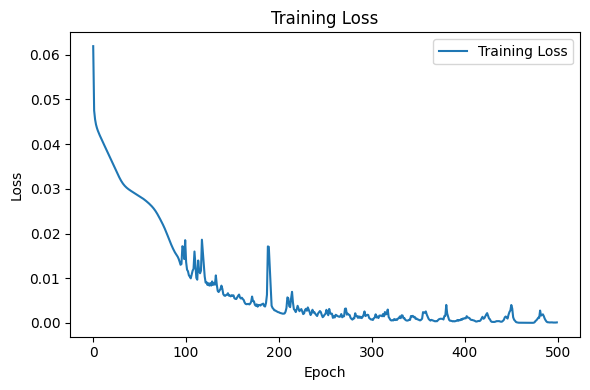

In [ ]:
plt.figure(figsize=(6, 4)) 
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [9]:
# Prediksi data training
train_predictions = model.predict(train_generator)

# Balikkan skala data prediksi dan data asli
train_predictions = scaler.inverse_transform(train_predictions)
y_train_original = scaler.inverse_transform(ytrain)

# Sesuaikan dimensi data
# Potong bagian awal dari y_train_original sesuai dengan window length
# dan sesuaikan panjang keduanya agar sama
y_true = y_train_original[win_length:]
y_pred = train_predictions[:len(y_true)]  # Potong prediksi agar sama panjang dengan y_true

# Pastikan kedua array memiliki dimensi yang sama
print("Shape y_true:", y_true.shape)
print("Shape y_pred:", y_pred.shape)

# Hitung MAE dan MAPE untuk data training
mae_train = mean_absolute_error(y_true, y_pred)
mape_train = mean_absolute_percentage_error(y_true, y_pred)*100

print(f"MAE train: {mae_train:.2f}")
print(f"MAPE train: {mape_train:.2f}%")


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Shape y_true: (30, 2)
Shape y_pred: (30, 2)
MAE train: 644.16
MAPE train: 4.53%


In [10]:
# Hitung MAE dan MAPE untuk Harga dan Produksi secara terpisah pada data training
mae_harga_train = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
mape_harga_train = mean_absolute_percentage_error(y_true[:, 0], y_pred[:, 0]) * 100
mae_produksi_train = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
mape_produksi_train = mean_absolute_percentage_error(y_true[:, 1], y_pred[:, 1]) * 100

print(f"MAE Harga train: {mae_harga_train:.2f}")
print(f"MAPE Harga train: {mape_harga_train:.2f}%")
print(f"MAE Produksi train: {mae_produksi_train:.2f}")
print(f"MAPE Produksi train: {mape_produksi_train:.2f}%")


MAE Harga train: 831.85
MAPE Harga train: 4.83%
MAE Produksi train: 456.46
MAPE Produksi train: 4.23%


In [11]:
# Melakukan inverse transform pada data
# Melakukan prediksi pada data uji
predictions = model.predict(test_generator)
predictions.shape

df_pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(xtest[:,0:][win_length:])],axis=1)

# Ambil hasil prediksi tanpa kolom target yang di-scale
predictions_only = df_pred.iloc[:, 0:num_features].values
#predictions_only


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [12]:
# Inversi transformasi scaler untuk mendapatkan nilai yang asli
rev_trans = scaler.inverse_transform(predictions_only)

# Buat dataframe baru dengan hasil prediksi yang telah di-inverse transformasi
df_rev_trans = pd.DataFrame(rev_trans, columns=df_input.columns)
# Ambil jumlah baris dari predictions_only
n = predictions_only.shape[0]

# Ambil kolom tanggal dari df (data awal) untuk n baris terakhir
tanggal_prediksi = data['Tanggal'].tail(n).values

# Tambahkan kolom tanggal pada hasil prediksi (df_rev_trans)
df_rev_trans.insert(0, 'Tanggal', tanggal_prediksi)

# Cetak dataframe hasil prediksi yang sudah lengkap dengan kolom tanggal
#print(df_rev_trans)

In [13]:
# Siapkan data asli test untuk perbandingan
y_test_original = scaler.inverse_transform(ytest)

# Sesuaikan dimensi data
y_true_test = y_test_original[win_length:]
y_pred_test = rev_trans[:len(y_true_test)]

# Pastikan kedua array memiliki dimensi yang sama
print("Shape y_true_test:", y_true_test.shape)
print("Shape y_pred_test:", y_pred_test.shape)

# Hitung MAE dan MAPE untuk data testing
mae_test = mean_absolute_error(y_true_test, y_pred_test)
mape_test = mean_absolute_percentage_error(y_true_test, y_pred_test)*100

print(f"MAE test: {mae_test:.2f}")
print(f"MAPE test: {mape_test:.2f}%")


Shape y_true_test: (18, 2)
Shape y_pred_test: (18, 2)
MAE test: 512.41
MAPE test: 2.89%


In [14]:
# Hitung MAE dan MAPE untuk Harga dan Produksi secara terpisah pada data testing
mae_harga_test = mean_absolute_error(y_true_test[:, 0], y_pred_test[:, 0])
mape_harga_test = mean_absolute_percentage_error(y_true_test[:, 0], y_pred_test[:, 0]) * 100
mae_produksi_test = mean_absolute_error(y_true_test[:, 1], y_pred_test[:, 1])
mape_produksi_test = mean_absolute_percentage_error(y_true_test[:, 1], y_pred_test[:, 1]) * 100

print(f"MAE Harga test: {mae_harga_test:.2f}")
print(f"MAPE Harga test: {mape_harga_test:.2f}%")
print(f"MAE Produksi test: {mae_produksi_test:.2f}")
print(f"MAPE Produksi test: {mape_produksi_test:.2f}%")


MAE Harga test: 697.28
MAPE Harga test: 2.33%
MAE Produksi test: 327.54
MAPE Produksi test: 3.46%


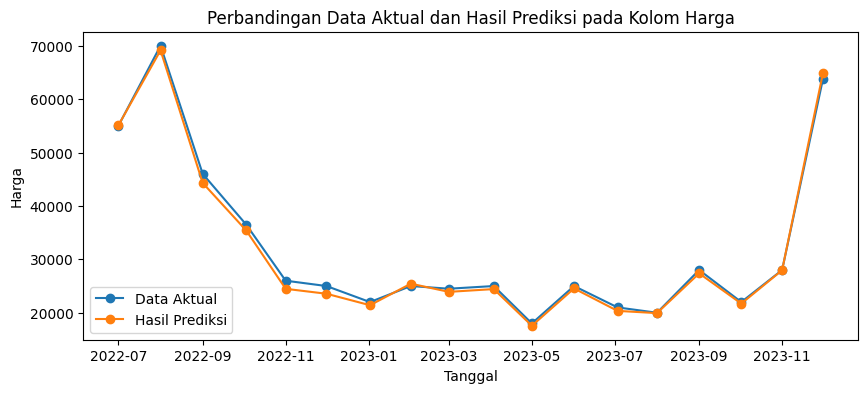

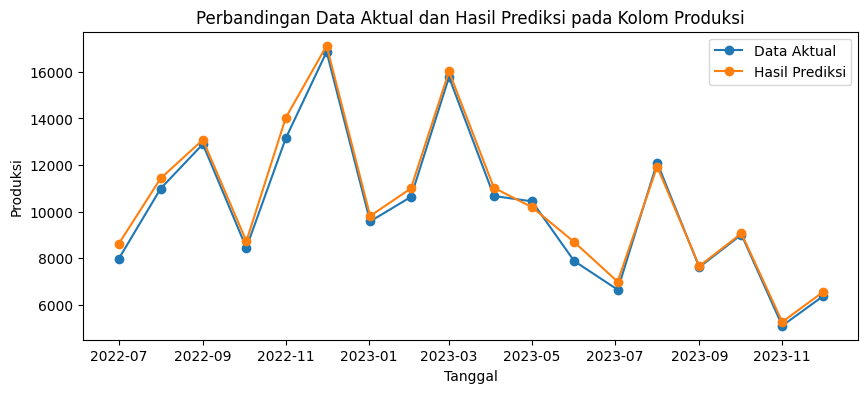

In [15]:
# Mengambil data pada kolom "Harga" dari baris ke-50 sampai ke-63
data_aktual = data.loc[42:63, "Harga"]
tanggal_aktual =  data.loc[42:63, "Tanggal"]

# Mengambil data hasil prediksi pada kolom "Harga"
data_prediksi = df_rev_trans["Harga"]
tanggal_prediksi =  df_rev_trans["Tanggal"]

# Membuat plot perbandingan
plt.figure(figsize=(10, 4))
plt.plot(tanggal_aktual, data_aktual, label='Data Aktual', marker='o')
plt.plot(tanggal_prediksi, data_prediksi, label='Hasil Prediksi', marker='o')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.title('Perbandingan Data Aktual dan Hasil Prediksi pada Kolom Harga')
plt.legend()
plt.grid(False)
plt.show()


# Mengambil data pada kolom "Produksi" dari baris ke-50 sampai ke-63
data_aktual = data.loc[42:63, "Produksi"]
tanggal_aktual =  data.loc[42:63, "Tanggal"]

# Mengambil data hasil prediksi pada kolom "Produksi"
data_prediksi = df_rev_trans["Produksi"]
tanggal_prediksi =  df_rev_trans["Tanggal"]

# Membuat plot perbandingan
plt.figure(figsize=(10,4 ))
plt.plot(tanggal_aktual, data_aktual, label='Data Aktual', marker='o')
plt.plot(tanggal_prediksi, data_prediksi, label='Hasil Prediksi', marker='o')
plt.xlabel('Tanggal')
plt.ylabel('Produksi')
plt.title('Perbandingan Data Aktual dan Hasil Prediksi pada Kolom Produksi')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
# Membuat DataFrame untuk perbandingan aktual dan prediksi
df_perbandingan = pd.DataFrame({'Tanggal': df_rev_trans['Tanggal'],
                                 'Harga_Aktual': data['Harga'].tail(n).values,
                                 'Harga_Prediksi': df_rev_trans['Harga'],
                                 'Produksi_Aktual': data['Produksi'].tail(n).values,
                                 'Produksi_Prediksi': df_rev_trans['Produksi']})

print(df_perbandingan)
# Simpan dataframe hasil prediksi yang sudah diubah formatnya ke file Excel
#df_perbandingan.to_excel("1layer.xlsx", index=False)


      Tanggal  Harga_Aktual  Harga_Prediksi  Produksi_Aktual  \
0  2022-07-01       55000.0    55092.675781          7960.40   
1  2022-08-01       70000.0    69139.585938         10991.89   
2  2022-09-01       46000.0    44306.589844         12897.16   
3  2022-10-03       36500.0    35402.902344          8450.65   
4  2022-11-01       26000.0    24479.210938         13153.70   
5  2022-12-01       25000.0    23556.798828         16856.96   
6  2023-01-02       22000.0    21408.843750          9582.20   
7  2023-02-01       25000.0    25440.267578         10632.80   
8  2023-03-01       24500.0    23911.113281         15771.60   
9  2023-04-03       25000.0    24431.191406         10672.40   
10 2023-05-01       18000.0    17569.542969         10442.95   
11 2023-06-01       25000.0    24546.144531          7883.05   
12 2023-07-03       21000.0    20350.439453          6651.50   
13 2023-08-01       20000.0    19929.212891         12104.65   
14 2023-09-01       28000.0    27377.416

In [23]:
# Setelah model selesai dilatih, simpan model dalam format H5
model.save('2layerfix.h5')

In [ ]:
from tensorflow.keras.models import load_model

# Pilih kolom yang akan di-scale
columns_to_scale = ['Harga', 'Produksi']
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(data[columns_to_scale]), columns=columns_to_scale)

# Load model yang telah dilatih sebelumnya
model = load_model("2layerfix.h5")

# Tentukan berapa bulan ke depan yang ingin diprediksi
num_months = 6

# Buat array kosong untuk menampung hasil prediksi
predictions_unscaled = []

# Ambil bulan dan tahun dari tanggal terakhir dalam data
last_date = data['Tanggal'].iloc[-1]
last_year = last_date.year

# Loop untuk melakukan prediksi selama 12 bulan
for _ in range(num_months):
    # Ambil data terakhir sebagai input untuk prediksi
    input_data = df_scaled.iloc[-model.input_shape[1]:].values.reshape(1, model.input_shape[1], len(columns_to_scale))

    # Lakukan prediksi
    predictions_scaled = model.predict(input_data)

    # Inversi transformasi scaler
    predictions_unscaled.append(scaler.inverse_transform(predictions_scaled).flatten())

    # Update data yang digunakan sebagai input untuk prediksi berikutnya
    new_data = pd.DataFrame(predictions_scaled, columns=columns_to_scale)
    df_scaled = pd.concat([df_scaled, new_data], ignore_index=True)

# Buat DataFrame dari hasil prediksi
predicted_df = pd.DataFrame(predictions_unscaled, columns=columns_to_scale)

# Buat DataFrame dengan tanggal dari Januari hingga Desember 2024
date_range = pd.date_range(start=f"{last_year+1}-01-01", periods=num_months, freq='M')
predicted_df.insert(0, 'Tanggal', date_range)
predicted_df
# Simpan DataFrame ke file Excel
#predicted_df.to_excel("hasil_prediksi_Kedepan.xlsx", index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


C:\Users\Acer\AppData\Local\Temp\ipykernel_11736\2685043765.py:43: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_range = pd.date_range(start=f"{last_year+1}-01-01", periods=num_months, freq='M')


,Tanggal,Harga,Produksi
0,2024-01-31,65858.546875,9292.446289
1,2024-02-29,31843.949219,12004.478516
2,2024-03-31,33378.007812,10109.343750
3,2024-04-30,16963.216797,12928.387695
4,2024-05-31,15386.421875,11743.158203
5,2024-06-30,25605.564453,7819.803223


In [25]:
weights = model.get_weights()
weights

[array([[ 0.46234733, -0.1652077 ,  0.33435592,  0.20892605,  0.05938925,
         -0.16600841,  0.11847673,  0.25368914,  0.3104178 ,  0.5017781 ,
         -0.0329861 ,  0.18647945,  0.276671  ,  0.1182529 ,  0.3307121 ,
         -0.29253128,  0.60724866,  0.4753135 ,  0.86539304,  0.0020482 ,
          0.10394814,  0.5325842 ,  0.5261649 , -0.01449441,  0.06246078,
          0.31362867,  0.9040146 ,  1.0676292 ,  0.5570107 ,  1.1501265 ,
          0.15793118,  0.26045328,  0.05027771, -0.00330484,  0.49858817,
          0.09028873, -0.99291915, -0.02334448,  0.2262741 ,  0.08239689,
          0.13112934,  0.58656245,  0.11672522,  0.47603133, -0.42136404,
         -0.08600758, -0.42094976, -0.45919445,  0.17104378, -0.15081637,
         -0.43469825,  1.176118  , -0.23802303,  0.02584122, -0.5018107 ,
          0.59098494, -0.18485776, -0.26698917, -0.7930325 ,  0.03897173,
          0.18782254, -0.7457788 , -0.24455881, -0.01939408,  0.40703386,
          0.07321119,  0.48834854, -0.

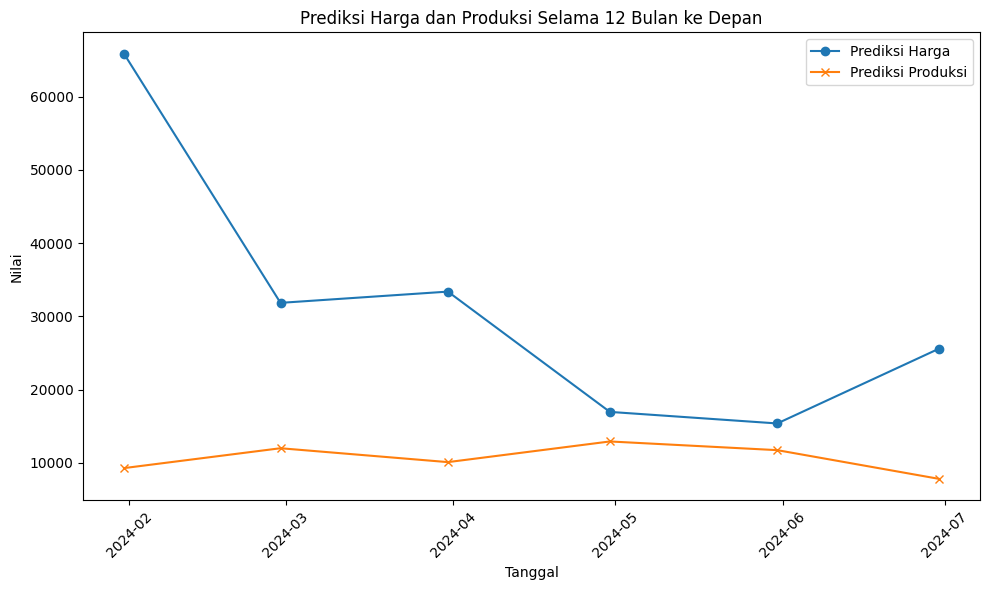

In [ ]:
# Buat figure untuk plot
plt.figure(figsize=(10, 6))

# Plot prediksi harga
plt.plot(predicted_df['Tanggal'], predicted_df['Harga'], label='Prediksi Harga', marker='o')

# Plot prediksi produksi
plt.plot(predicted_df['Tanggal'], predicted_df['Produksi'], label='Prediksi Produksi', marker='x')

# Menambahkan judul dan label sumbu
plt.title('Prediksi Harga dan Produksi Selama 12 Bulan ke Depan')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')

# Menambahkan legenda
plt.legend()

# Memutar label tanggal agar lebih rapi
plt.xticks(rotation=45)

# Menampilkan plot
plt.tight_layout()
plt.show()


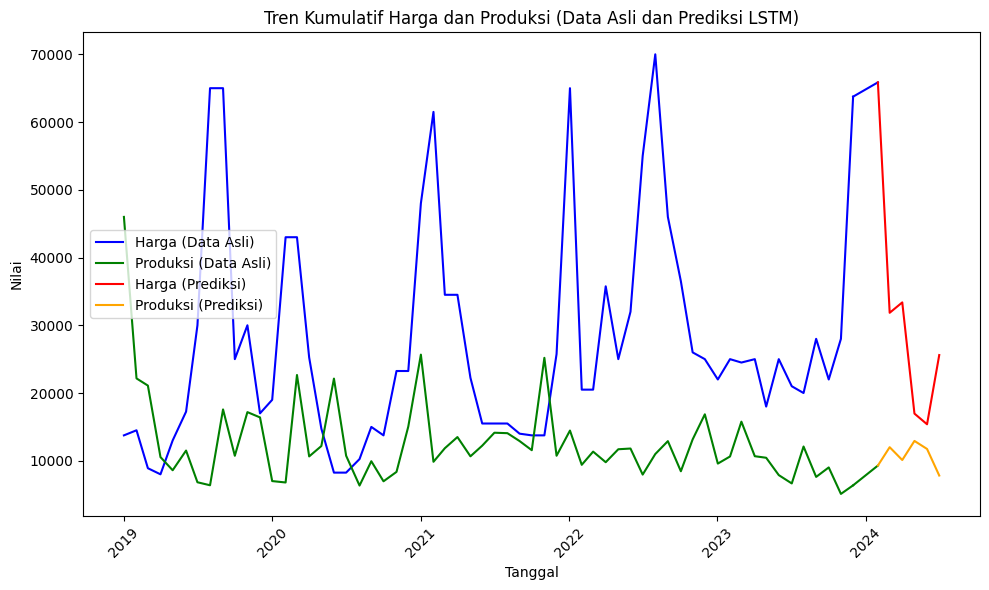

In [ ]:
# Pastikan data diurutkan berdasarkan tanggal
data = data.sort_values(by="Tanggal")
predicted_df = predicted_df.sort_values(by="Tanggal")

plt.figure(figsize=(10, 6))

# Plot data asli dengan garis penuh
plt.plot(data['Tanggal'], data['Harga'], label='Harga (Data Asli)', color='blue', linestyle='-')
plt.plot(data['Tanggal'], data['Produksi'], label='Produksi (Data Asli)', color='green', linestyle='-')

# Hubungkan titik terakhir data asli dengan titik pertama prediksi
plt.plot([data['Tanggal'].iloc[-1], predicted_df['Tanggal'].iloc[0]], 
         [data['Harga'].iloc[-1], predicted_df['Harga'].iloc[0]], 
         color='blue', linestyle='-')  # Menyambungkan harga

plt.plot([data['Tanggal'].iloc[-1], predicted_df['Tanggal'].iloc[0]], 
         [data['Produksi'].iloc[-1], predicted_df['Produksi'].iloc[0]], 
         color='green', linestyle='-')  # Menyambungkan produksi

# Plot prediksi dengan garis penuh tetapi warna berbeda
plt.plot(predicted_df['Tanggal'], predicted_df['Harga'], label='Harga (Prediksi)', color='red', linestyle='-')
plt.plot(predicted_df['Tanggal'], predicted_df['Produksi'], label='Produksi (Prediksi)', color='orange', linestyle='-')

# Menambahkan judul dan label sumbu
plt.title("Tren Kumulatif Harga dan Produksi (Data Asli dan Prediksi LSTM)")
plt.xlabel("Tanggal")
plt.ylabel("Nilai")

# Menambahkan legenda
plt.legend()

# Memutar label tanggal agar lebih rapi
plt.xticks(rotation=45)

# Menampilkan plot
plt.tight_layout()
plt.show()


In [ ]:
# Data from the table
df = df_perbandingan

# Calculate MAE and MAPE for Harga and Produksi
df['MAE_Harga'] = abs(df['Harga_Aktual'] - df['Harga_Prediksi'])
df['MAPE_Harga'] = (df['MAE_Harga'] / df['Harga_Aktual']) * 100

df['MAE_Produksi'] = abs(df['Produksi_Aktual'] - df['Produksi_Prediksi'])
df['MAPE_Produksi'] = (df['MAE_Produksi'] / df['Produksi_Aktual']) * 100

# Display the dataframe and summary statistics
df, df[['MAE_Harga', 'MAPE_Harga', 'MAE_Produksi', 'MAPE_Produksi']].mean()
#df.to_excel("Perhitunganmaemape.xlsx", index=False)



(      Tanggal  Harga_Aktual  Harga_Prediksi  Produksi_Aktual  \
 0  2022-07-01       55000.0    55092.675781          7960.40   
 1  2022-08-01       70000.0    69139.585938         10991.89   
 2  2022-09-01       46000.0    44306.589844         12897.16   
 3  2022-10-03       36500.0    35402.902344          8450.65   
 4  2022-11-01       26000.0    24479.210938         13153.70   
 5  2022-12-01       25000.0    23556.798828         16856.96   
 6  2023-01-02       22000.0    21408.843750          9582.20   
 7  2023-02-01       25000.0    25440.267578         10632.80   
 8  2023-03-01       24500.0    23911.113281         15771.60   
 9  2023-04-03       25000.0    24431.191406         10672.40   
 10 2023-05-01       18000.0    17569.542969         10442.95   
 11 2023-06-01       25000.0    24546.144531          7883.05   
 12 2023-07-03       21000.0    20350.439453          6651.50   
 13 2023-08-01       20000.0    19929.212891         12104.65   
 14 2023-09-01       2800